# Vehicle Registrations in Malaysia in 2025
*source: data.gov.my*

# Load Data

In [1]:
# If not already installed, do: pip install pandas fastparquet
import pandas as pd
import numpy as np

# 2024 data
URL_DATA_2024 = 'https://storage.data.gov.my/transportation/cars_2024.parquet'
# 2025 data
URL_DATA_2025 = 'https://storage.data.gov.my/transportation/cars_2025.parquet'
# 2026 data
URL_DATA_2026 = 'https://storage.data.gov.my/transportation/cars_2026.parquet'


# Load 2026 data
df_2026 = pd.read_parquet(URL_DATA_2026)
if 'date' in df_2026.columns: df_2026['date'] = pd.to_datetime(df_2026['date'])

# Load 2025 data
df_2025 = pd.read_parquet(URL_DATA_2025)
if 'date' in df_2025.columns: df_2025['date'] = pd.to_datetime(df_2025['date'])

# Load 2024 data
df_2024 = pd.read_parquet(URL_DATA_2024)
if 'date' in df_2024.columns: df_2024['date'] = pd.to_datetime(df_2024['date'])

# Concatenate the three dataframes
df = pd.concat([df_2024, df_2025, df_2026], ignore_index=True)


print(df)

          date_reg                      type   maker        model  colour  \
0       2024-01-01                       jip   Chery      Omoda 5   black   
1       2024-01-01                       jip   Chery      Omoda 5   white   
2       2024-01-01                       jip   Chery      Omoda 5   white   
3       2024-01-01                   pick_up    Ford       Ranger   black   
4       2024-01-01                   pick_up    Ford       Ranger   black   
...            ...                       ...     ...          ...     ...   
2293036 2026-08-31  motokar_pelbagai_utiliti  Toyota        Veloz  silver   
2293037 2026-08-31                   motokar  Toyota         Vios   black   
2293038 2026-08-31                   motokar  Toyota         Vios   black   
2293039 2026-08-31                       jip  Toyota  Yaris Cross  silver   
2293040 2026-08-31                       jip   Zeekr           7X    grey   

                fuel        state  
0             petrol  Rakan Niaga  
1  

In [2]:
print(df.tail(100))

          date_reg                      type   maker        model  colour  \
2292941 2026-08-31                   motokar  Proton         Saga    grey   
2292942 2026-08-31                   motokar  Proton         Saga  silver   
2292943 2026-08-31                   motokar  Proton         Saga    blue   
2292944 2026-08-31                   motokar  Proton         Saga   white   
2292945 2026-08-31                   motokar  Proton         Saga    grey   
...            ...                       ...     ...          ...     ...   
2293036 2026-08-31  motokar_pelbagai_utiliti  Toyota        Veloz  silver   
2293037 2026-08-31                   motokar  Toyota         Vios   black   
2293038 2026-08-31                   motokar  Toyota         Vios   black   
2293039 2026-08-31                       jip  Toyota  Yaris Cross  silver   
2293040 2026-08-31                       jip   Zeekr           7X    grey   

             fuel        state  
2292941    petrol  Rakan Niaga  
2292942  

# **Analyze data**

In [3]:
maker_counts = df['maker'].value_counts()

# Calculate the percentage
maker_percentages = maker_counts / len(df) * 100

# Combine into a single DataFrame for display
top_makers = pd.DataFrame({
    'Count': maker_counts,
    'Percentage (%)': maker_percentages
})

# Sort by count in descending order and display the top 20
print(top_makers.sort_values(by='Count', ascending=False).head(20))

                Count  Percentage (%)
maker                                
Perodua        937563       40.887320
Proton         434317       18.940656
Toyota         329207       14.356786
Honda          197913        8.631028
Chery           72559        3.164313
Mitsubishi      38868        1.695042
Mazda           32230        1.405557
BYD             30449        1.327887
Mercedes Benz   25829        1.126408
BMW             22118        0.964571
Isuzu           16841        0.734440
Lexus           16776        0.731605
Nissan          16395        0.714989
Tesla           16151        0.704349
Great Wall      12612        0.550012
Ford            12600        0.549489
Jetour          10249        0.446961
Porsche          6655        0.290226
Mini             5791        0.252547
Zeekr            5592        0.243868


**Reasoning**:
The 'date_reg' column is not in datetime format, causing the AttributeError. Convert 'date_reg' to datetime format first, then extract the month, group by month and fuel, count the entries, and reset the index.



In [4]:
df['date_reg'] = pd.to_datetime(df['date_reg'])
df['month'] = df['date_reg'].dt.month
df_grouped_monthly = df.groupby(['month', 'fuel']).size().reset_index(name='count')
print(df_grouped_monthly)

    month           fuel   count
0       1         diesel     947
1       1       electric    9333
2       1    greendiesel    9616
3       1  hybrid_diesel       2
4       1  hybrid_petrol    6503
..    ...            ...     ...
70     12       electric   10704
71     12    greendiesel   12584
72     12  hybrid_diesel       3
73     12  hybrid_petrol    7295
74     12         petrol  150294

[75 rows x 3 columns]


## Calculate electric car percentage

### Subtask:
Calculate the percentage of electric cars for each month.


**Reasoning**:
Filter the grouped DataFrame to get only electric cars, group the original grouped DataFrame by month to get total counts, merge these two DataFrames, calculate the electric car percentage, and display the result as requested in the instructions.



In [5]:
# Filter the df_grouped_monthly DataFrame to get only the rows where the 'fuel' type is 'electric'.
df_electric_monthly = df_grouped_monthly[df_grouped_monthly['fuel'] == 'electric']

# Group the original df_grouped_monthly DataFrame by 'month' and sum the counts to get the total number of cars for each month.
df_total_monthly = df_grouped_monthly.groupby('month')['count'].sum().reset_index(name='total_count')

# Merge df_total_monthly and df_electric_monthly DataFrames on 'month'.
# Use a left merge on df_total_monthly to include all months, even if there are no electric cars (fillna(0)).
df_merged_monthly = pd.merge(df_total_monthly, df_electric_monthly, on='month', how='left').fillna(0)

# Rename the count column from df_electric_monthly to 'electric_count' for clarity.
df_merged_monthly = df_merged_monthly.rename(columns={'count': 'electric_count'})

# Calculate the percentage of electric cars for each month.
df_merged_monthly['electric_percentage'] = (df_merged_monthly['electric_count'] / df_merged_monthly['total_count']) * 100

# Print the first few rows of the resulting DataFrame.
display(df_merged_monthly)

,month,total_count,fuel,electric_count,electric_percentage
0,1,192098,electric,9333,4.858458
1,2,190937,electric,6821,3.572383
2,3,219989,electric,9953,4.524317
3,4,206531,electric,10395,5.033143
4,5,214334,electric,11643,5.432176
5,6,192985,electric,11399,5.906677
6,7,232689,electric,11613,4.990782
7,8,232310,electric,14068,6.055701
8,9,123658,electric,5045,4.079801
9,10,156441,electric,5914,3.780339


## Visualize the trend

### Subtask:
Plot the percentage of electric cars over time (monthly).


**Reasoning**:
Plot the percentage of electric cars over time using the calculated monthly percentages.



### Calculate electric car percentage for 2024 and 2025 separately

In [6]:
# Ensure 'date_reg' is in datetime format for both dataframes
df_2024['date_reg'] = pd.to_datetime(df_2024['date_reg'])
df_2025['date_reg'] = pd.to_datetime(df_2025['date_reg'])
df_2026['date_reg'] = pd.to_datetime(df_2026['date_reg'])

# Calculate monthly electric car percentage for 2024
df_grouped_monthly_2024 = df_2024.groupby([df_2024['date_reg'].dt.month, 'fuel']).size().reset_index(name='count')
df_electric_monthly_2024 = df_grouped_monthly_2024[df_grouped_monthly_2024['fuel'] == 'electric']
df_total_monthly_2024 = df_grouped_monthly_2024.groupby('date_reg')['count'].sum().reset_index(name='total_count')
df_merged_monthly_2024 = pd.merge(df_total_monthly_2024, df_electric_monthly_2024, left_on='date_reg', right_on='date_reg', how='left').fillna(0)
df_merged_monthly_2024 = df_merged_monthly_2024.rename(columns={'count': 'electric_count', 'date_reg': 'month'})
df_merged_monthly_2024 = df_merged_monthly_2024[['month', 'total_count', 'fuel', 'electric_count']] # Reorder columns for clarity


# Calculate the percentage for 2024
df_merged_monthly_2024['electric_percentage'] = (df_merged_monthly_2024['electric_count'] / df_merged_monthly_2024['total_count']) * 100


# Calculate monthly electric car percentage for 2025
df_grouped_monthly_2025 = df_2025.groupby([df_2025['date_reg'].dt.month, 'fuel']).size().reset_index(name='count')
df_electric_monthly_2025 = df_grouped_monthly_2025[df_grouped_monthly_2025['fuel'] == 'electric']
df_total_monthly_2025 = df_grouped_monthly_2025.groupby('date_reg')['count'].sum().reset_index(name='total_count')
df_merged_monthly_2025 = pd.merge(df_total_monthly_2025, df_electric_monthly_2025, left_on='date_reg', right_on='date_reg', how='left').fillna(0)
df_merged_monthly_2025 = df_merged_monthly_2025.rename(columns={'count': 'electric_count', 'date_reg': 'month'})
df_merged_monthly_2025 = df_merged_monthly_2025[['month', 'total_count', 'fuel', 'electric_count']] # Reorder columns for clarity


# Calculate the percentage for 2025
df_merged_monthly_2025['electric_percentage'] = (df_merged_monthly_2025['electric_count'] / df_merged_monthly_2025['total_count']) * 100

# Calculate monthly electric car percentage for 2026
df_grouped_monthly_2026 = df_2026.groupby([df_2026['date_reg'].dt.month, 'fuel']).size().reset_index(name='count')
df_electric_monthly_2026 = df_grouped_monthly_2026[df_grouped_monthly_2026['fuel'] == 'electric']
df_total_monthly_2026 = df_grouped_monthly_2026.groupby('date_reg')['count'].sum().reset_index(name='total_count')
df_merged_monthly_2026 = pd.merge(df_total_monthly_2026, df_electric_monthly_2026, left_on='date_reg', right_on='date_reg', how='left').fillna(0)
df_merged_monthly_2026 = df_merged_monthly_2026.rename(columns={'count': 'electric_count', 'date_reg': 'month'})
df_merged_monthly_2026 = df_merged_monthly_2026[['month', 'total_count', 'fuel', 'electric_count']] # Reorder columns for clarity


# Calculate the percentage for 2025
df_merged_monthly_2026['electric_percentage'] = (df_merged_monthly_2026['electric_count'] / df_merged_monthly_2026['total_count']) * 100


display(df_merged_monthly_2024)
display(df_merged_monthly_2025)
display(df_merged_monthly_2026)

,month,total_count,fuel,electric_count,electric_percentage
0,1,70183,electric,1403,1.999060
1,2,66934,electric,1026,1.532853
2,3,75063,electric,2260,3.010804
3,4,63522,electric,1609,2.532981
4,5,73900,electric,2453,3.319350
5,6,61202,electric,1912,3.124081
6,7,77024,electric,1884,2.445991
7,8,76064,electric,1774,2.332247
8,9,61071,electric,1513,2.477444
9,10,75037,electric,1569,2.090968


,month,total_count,fuel,electric_count,electric_percentage
0,1,53926,electric,1691,3.135779
1,2,67320,electric,2160,3.208556
2,3,77103,electric,2976,3.859772
3,4,65190,electric,2892,4.436263
4,5,74381,electric,4152,5.582071
5,6,58840,electric,3272,5.560843
6,7,75635,electric,2792,3.691413
7,8,78970,electric,3461,4.382677
8,9,62587,electric,3532,5.643344
9,10,81404,electric,4345,5.337576


,month,total_count,fuel,electric_count,electric_percentage
0,1,67989,electric,6239,9.176484
1,2,56683,electric,3635,6.412857
2,3,67823,electric,4717,6.954868
3,4,77819,electric,5894,7.573986
4,5,66053,electric,5038,7.627208
5,6,72943,electric,6215,8.520352
6,7,80030,electric,6937,8.668000
7,8,77276,electric,8833,11.430457


### Overlay the plots

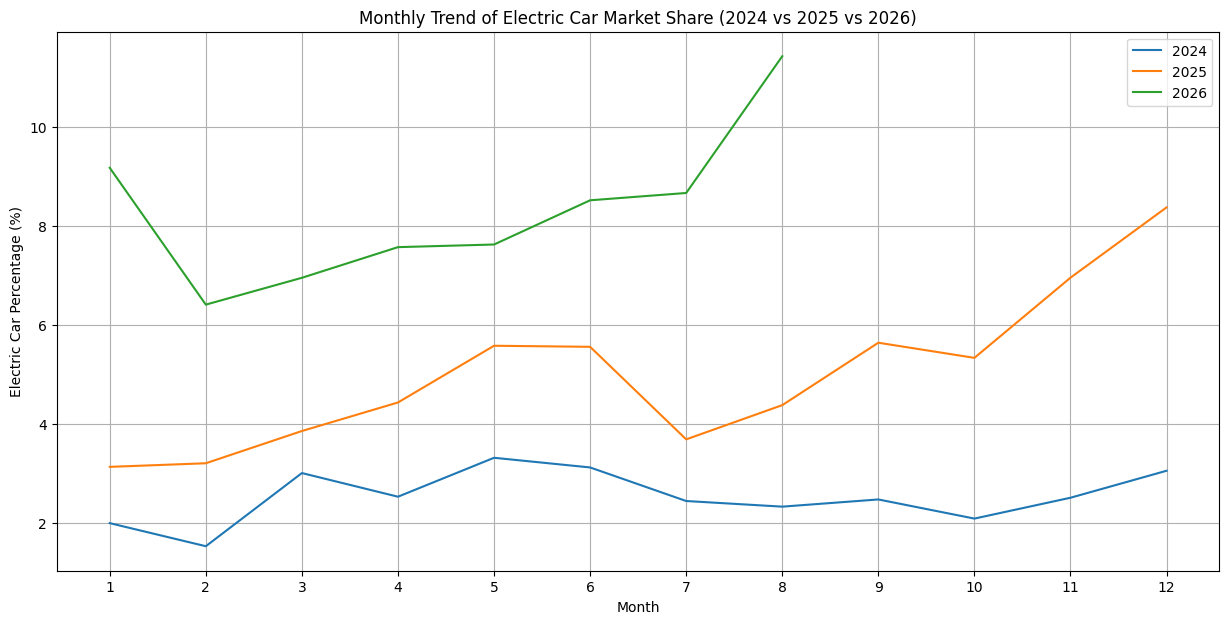

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df_merged_monthly_2024['month'], df_merged_monthly_2024['electric_percentage'], label='2024')
plt.plot(df_merged_monthly_2025['month'], df_merged_monthly_2025['electric_percentage'], label='2025')
plt.plot(df_merged_monthly_2026['month'], df_merged_monthly_2026['electric_percentage'], label='2026')
plt.xlabel('Month')
plt.ylabel('Electric Car Percentage (%)')
plt.title('Monthly Trend of Electric Car Market Share (2024 vs 2025 vs 2026)')
plt.xticks(df_merged_monthly_2024['month'])
plt.legend()
plt.grid(True)
plt.show()

## Summary:

### Data Analysis Key Findings

*   The percentage of electric cars for each month was successfully calculated and stored in the `electric_percentage` column of the `df_merged_monthly` DataFrame.
*   A line plot was generated showing the monthly trend of electric car market share.

### Insights or Next Steps

*   Analyze the plot to identify any trends or seasonality in electric car market share.
*   Compare the electric car market share with other fuel types to get a broader market perspective.


In [8]:
# prompt: show the top 10 electric car models and makers in 2024 and 2025 separately

# Filter the DataFrames to include only electric cars for 2024, 2025 and 2026
electric_cars_df_2024 = df_2024[df_2024['fuel'] == 'electric'].copy()
electric_cars_df_2025 = df_2025[df_2025['fuel'] == 'electric'].copy()
electric_cars_df_2026 = df_2026[df_2026['fuel'] == 'electric'].copy()

# Combine 'maker' and 'model' into a single column for easier analysis of combinations for 2024
electric_cars_df_2024['maker_model'] = electric_cars_df_2024['maker'] + ' - ' + electric_cars_df_2024['model']

# Count the occurrences of each 'maker_model' combination for 2024
maker_model_counts_2024 = electric_cars_df_2024['maker_model'].value_counts()

# Get all electric car models and makers for 2024
all_electric_models_makers_2024 = maker_model_counts_2024

# Combine 'maker' and 'model' into a single column for easier analysis of combinations for 2025
electric_cars_df_2025['maker_model'] = electric_cars_df_2025['maker'] + ' - ' + electric_cars_df_2025['model']

# Count the occurrences of each 'maker_model' combination for 2025
maker_model_counts_2025 = electric_cars_df_2025['maker_model'].value_counts()

# Get all electric car models and makers for 2025
all_electric_models_makers_2025 = maker_model_counts_2025

# Combine 'maker' and 'model' into a single column for easier analysis of combinations for 2026
electric_cars_df_2026['maker_model'] = electric_cars_df_2026['maker'] + ' - ' + electric_cars_df_2026['model']

# Count the occurrences of each 'maker_model' combination for 2026
maker_model_counts_2026 = electric_cars_df_2026['maker_model'].value_counts()

# Get all electric car models and makers for 2026
all_electric_models_makers_2026 = maker_model_counts_2026


# Merge the series for 2024, 2025, and 2026 based on the 'maker_model' index
merged_sales = pd.merge(all_electric_models_makers_2024, all_electric_models_makers_2025, left_index=True, right_index=True, how='outer', suffixes=('_2024', '_2025')).fillna(0)
merged_sales = pd.merge(merged_sales, all_electric_models_makers_2026, left_index=True, right_index=True, how='outer').fillna(0)
merged_sales = merged_sales.rename(columns={'count': 'count_2026'})

# Calculate the year-over-year change percentage (2025 vs 2026), handling division by zero
merged_sales['YOY Change (%)'] = ((merged_sales['count_2026'] - merged_sales['count_2025']) / merged_sales['count_2025'] * 100).replace([np.inf, -np.inf], np.nan).fillna(0)


# Sort by the total count in 2026 for easier comparison of top performers in the latest year
merged_sales_sorted = merged_sales.sort_values(by='count_2026', ascending=False)

print("\nElectric Car Model and Maker Sales Comparison (2024, 2025 vs 2026):")
display(merged_sales_sorted.head(20)) # Display top 20 based on 2026 sales


Electric Car Model and Maker Sales Comparison (2024, 2025 vs 2026):


,count_2024,count_2025,count_2026,YOY Change (%)
maker_model,,,,
Proton - e.MAS 5,0.0,213.0,17837.0,8274.178404
Proton - e.MAS 7,0.0,8677.0,4004.0,-53.855019
BYD - Atto 3,2969.0,4069.0,3027.0,-25.608258
Zeekr - 7X,0.0,1510.0,2449.0,62.185430
Tesla - Model Y,2300.0,4401.0,1978.0,-55.055669
Chery - iCaur V23,0.0,41.0,1812.0,4319.512195
Tesla - Model 3,2823.0,2880.0,1755.0,-39.062500
BYD - Sealion,641.0,4454.0,1456.0,-67.310283
BYD - Seal 6,0.0,1279.0,1326.0,3.674746


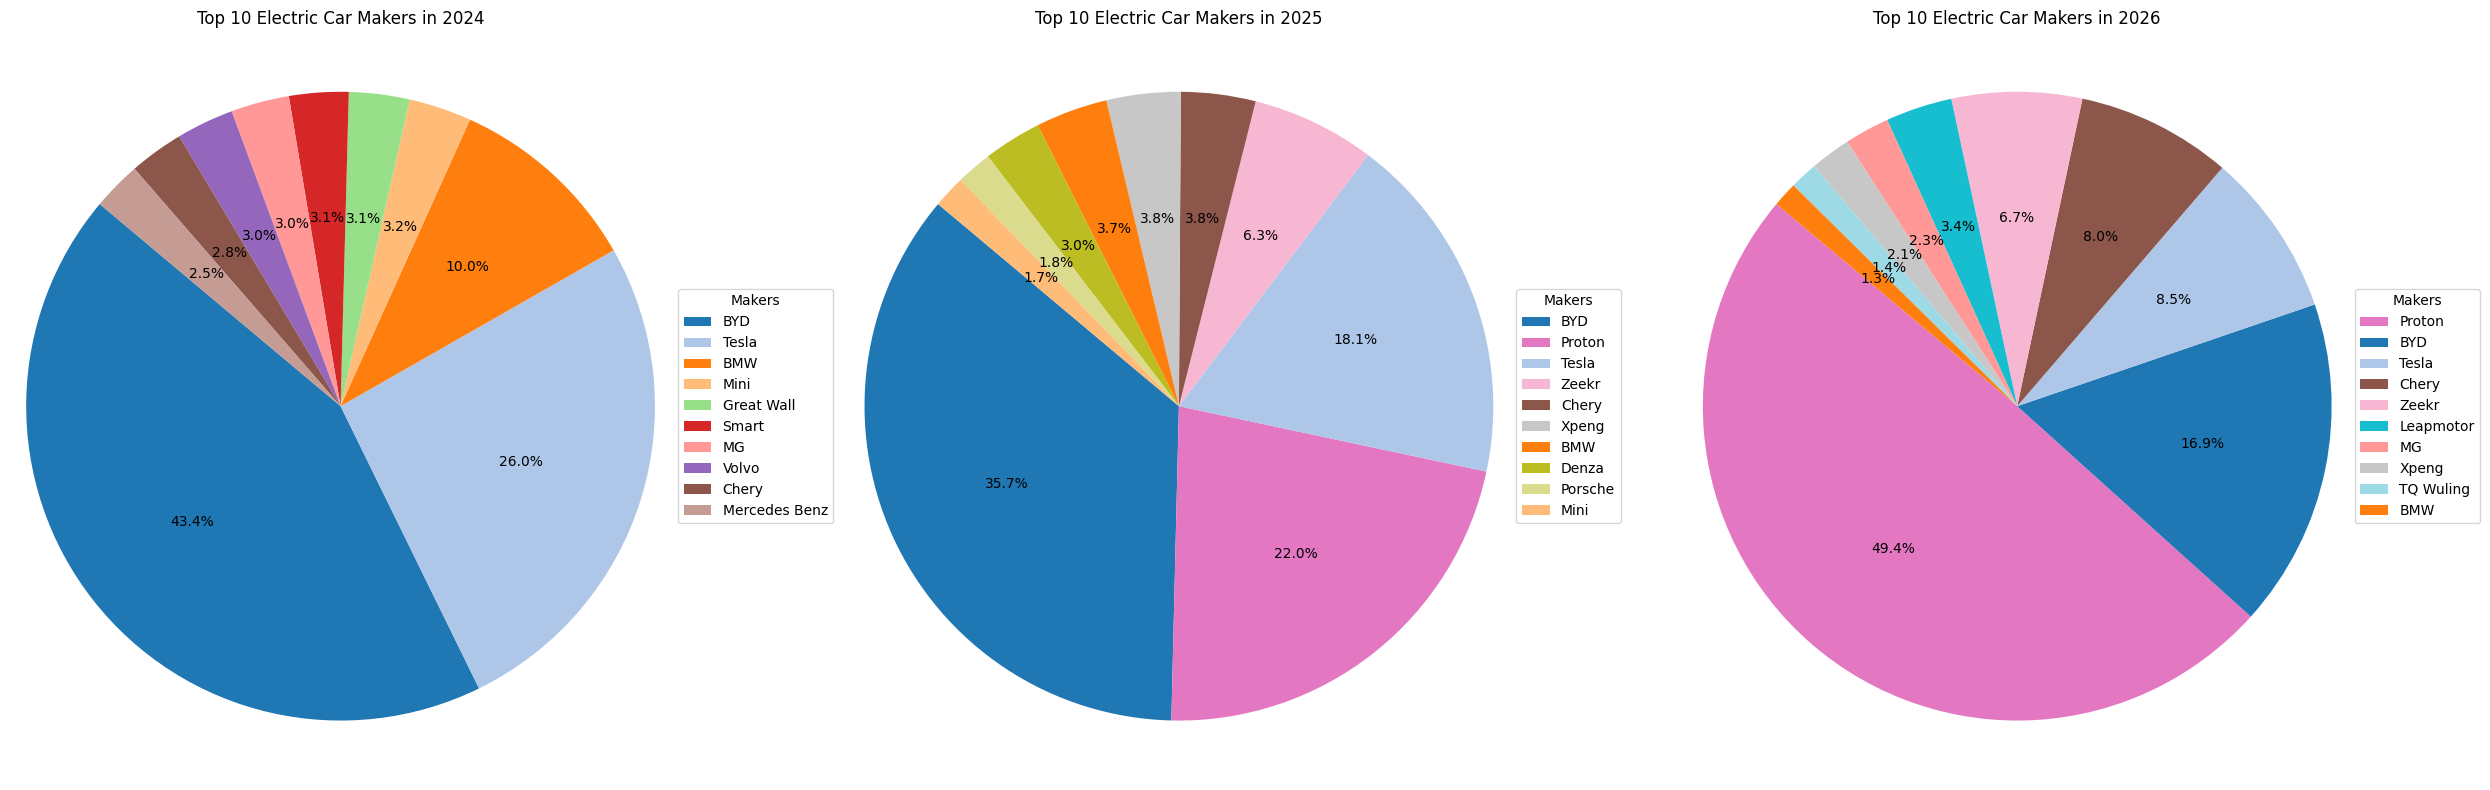

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Filter for electric cars in 2024 and group by maker
electric_cars_2024 = df_2024[df_2024['fuel'] == 'electric']
maker_counts_electric_2024 = electric_cars_2024['maker'].value_counts().head(10)

# Filter for electric cars in 2025 and group by maker
electric_cars_2025 = df_2025[df_2025['fuel'] == 'electric']
maker_counts_electric_2025 = electric_cars_2025['maker'].value_counts().head(10)

# Filter for electric cars in 2026 and group by maker
electric_cars_2026 = df_2026[df_2026['fuel'] == 'electric']
maker_counts_electric_2026 = electric_cars_2026['maker'].value_counts().head(10)

# Get all unique makers from all three years' top 10
all_makers = pd.concat([maker_counts_electric_2024, maker_counts_electric_2025, maker_counts_electric_2026]).index.unique()

# Create a color map for all unique makers
colors = plt.cm.tab20(np.linspace(0, 1, len(all_makers)))
color_map = dict(zip(all_makers, colors))

# Create a figure with three subplots
fig, axes = plt.subplots(1, 3, figsize=(25, 8))

# Plot pie chart for 2024 on the left subplot
colors_2024 = [color_map[maker] for maker in maker_counts_electric_2024.index]
wedges2024, texts2024, autotexts2024 = axes[0].pie(maker_counts_electric_2024, autopct='%1.1f%%', startangle=140, colors=colors_2024)
axes[0].set_title('Top 10 Electric Car Makers in 2024')
axes[0].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Add legend with color-coded labels for 2024
axes[0].legend(wedges2024, maker_counts_electric_2024.index,
               title="Makers",
               loc="center left",
               bbox_to_anchor=(1, 0, 0.5, 1))

# Plot pie chart for 2025 on the middle subplot
colors_2025 = [color_map[maker] for maker in maker_counts_electric_2025.index]
wedges2025, texts2025, autotexts2025 = axes[1].pie(maker_counts_electric_2025, autopct='%1.1f%%', startangle=140, colors=colors_2025)
axes[1].set_title('Top 10 Electric Car Makers in 2025')
axes[1].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Add legend with color-coded labels for 2025
axes[1].legend(wedges2025, maker_counts_electric_2025.index,
               title="Makers",
               loc="center left",
               bbox_to_anchor=(1, 0, 0.5, 1))

# Plot pie chart for 2026 on the right subplot
colors_2026 = [color_map[maker] for maker in maker_counts_electric_2026.index]
wedges2026, texts2026, autotexts2026 = axes[2].pie(maker_counts_electric_2026, autopct='%1.1f%%', startangle=140, colors=colors_2026)
axes[2].set_title('Top 10 Electric Car Makers in 2026')
axes[2].axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Add legend with color-coded labels for 2026
axes[2].legend(wedges2026, maker_counts_electric_2026.index,
               title="Makers",
               loc="center left",
               bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

In [10]:
# prompt: show the top 20 cars registered in 2024 and 2025 separately in a table. The table should have columns on models, makers, type of fuel, and type. Sort them according to the number of cars solds

# Group by model, maker, fuel, and type, and count the occurrences for 2024
car_counts_2024 = df_2024.groupby(['model', 'maker', 'fuel', 'type']).size().reset_index(name='sold_count')

# Sort by the number of cars sold in descending order for 2024
car_counts_sorted_2024 = car_counts_2024.sort_values(by='sold_count', ascending=False)

# Get the top 20 cars for 2024
top_20_cars_2024 = car_counts_sorted_2024.head(20)

# Display the result in a table for 2024
print("\nTop 20 Cars Registered in 2024:")
print(top_20_cars_2024.to_string(index=False))

# Group by model, maker, fuel, and type, and count the occurrences for 2025
car_counts_2025 = df_2025.groupby(['model', 'maker', 'fuel', 'type']).size().reset_index(name='sold_count')

# Sort by the number of cars sold in descending order for 2025
car_counts_sorted_2025 = car_counts_2025.sort_values(by='sold_count', ascending=False)

# Get the top 20 cars for 2025
top_20_cars_2025 = car_counts_sorted_2025.head(20)

# Display the result in a table for 2025
print("\nTop 20 Cars Registered in 2025:")
print(top_20_cars_2025.to_string(index=False))

# Group by model, maker, fuel, and type, and count the occurrences for 2026
car_counts_2026 = df_2026.groupby(['model', 'maker', 'fuel', 'type']).size().reset_index(name='sold_count')

# Sort by the number of cars sold in descending order for 2026
car_counts_sorted_2026 = car_counts_2026.sort_values(by='sold_count', ascending=False)

# Get the top 20 cars for 2026
top_20_cars_2026 = car_counts_sorted_2026.head(20)

# Display the result in a table for 2026
print("\nTop 20 Cars Registered in 2026:")
print(top_20_cars_2026.to_string(index=False))


Top 20 Cars Registered in 2024:
  model      maker        fuel                     type  sold_count
  Bezza    Perodua      petrol                  motokar      100813
   Axia    Perodua      petrol                  motokar       88137
   Myvi    Perodua      petrol                  motokar       72214
   Saga     Proton      petrol                  motokar       69863
   Alza    Perodua      petrol motokar_pelbagai_utiliti       44374
  Ativa    Perodua      petrol                      jip       36039
   Vios     Toyota      petrol                  motokar       28657
   City      Honda      petrol                  motokar       26920
  Hilux     Toyota greendiesel                  pick_up       26727
    X50     Proton      petrol                      jip       22674
    S70     Proton      petrol                  motokar       18880
Persona     Proton      petrol                  motokar       18839
   HR-V      Honda      petrol                  motokar       17717
   Aruz    Pero

In [11]:
# Filter for electric cars in January 2026
electric_cars_jan_2026 = df_2026[(df_2026['fuel'] == 'electric') & (df_2026['date_reg'].dt.month == 1)].copy()
sales_jan_2026 = electric_cars_jan_2026.groupby(['model', 'maker']).size().reset_index(name='sold_count_jan_2026')

# Filter for electric cars in January 2025
electric_cars_jan_2025 = df_2025[(df_2025['fuel'] == 'electric') & (df_2025['date_reg'].dt.month == 1)].copy()
sales_jan_2025 = electric_cars_jan_2025.groupby(['model', 'maker']).size().reset_index(name='sold_count_jan_2025')

# Merge the 2026 and 2025 sales data
merged_jan_sales = pd.merge(sales_jan_2026, sales_jan_2025, on=['model', 'maker'], how='left').fillna(0)

# Calculate Year-over-Year change
merged_jan_sales['YOY Change (%)'] = ((merged_jan_sales['sold_count_jan_2026'] - merged_jan_sales['sold_count_jan_2025']) / merged_jan_sales['sold_count_jan_2025'] * 100).replace([np.inf, -np.inf], np.nan).fillna(0)

# Sort by sold_count_jan_2026 to get top 10 for 2026
top_10_ev_jan_2026 = merged_jan_sales.sort_values(by='sold_count_jan_2026', ascending=False).head(10)

print("Top 10 Electric Cars in January 2026 with YOY Change:")
display(top_10_ev_jan_2026)

Top 10 Electric Cars in January 2026 with YOY Change:


,model,maker,sold_count_jan_2026,sold_count_jan_2025,YOY Change (%)
50,e.MAS 5,Proton,3068,0.0,0.000000
2,7X,Zeekr,426,0.0,0.000000
5,Atto 3,BYD,389,104.0,274.038462
57,iCaur V23,Chery,268,0.0,0.000000
51,e.MAS 7,Proton,208,421.0,-50.593824
39,Sealion,BYD,196,151.0,29.801325
38,Seal 6,BYD,195,0.0,0.000000
56,iCaur 03,Chery,183,0.0,0.000000
6,B10,Leapmotor,100,0.0,0.000000
30,Model 3,Tesla,91,3.0,2933.333333


In [12]:
import pandas as pd

# Diagnostic: Check fuel types for e.MAS 7 in April 2026
ema7_apr_26_raw = df_2026[(df_2026['maker'] == 'Proton') & (df_2026['model'].str.strip() == 'e.MAS 7') & (df_2026['date_reg'].dt.month == 4)]
print("Fuel types for e.MAS 7 in April 2026:")
print(ema7_apr_26_raw['fuel'].value_counts())

# Re-generate the top 10 list, ensuring we capture all e.MAS models regardless of potential fuel labeling errors
mask_apr_26 = (df_2026['date_reg'].dt.month == 4) & ((df_2026['fuel'] == 'electric') | (df_2026['model'].str.contains('e.MAS')))
apr_2026_ev = df_2026[mask_apr_26].copy()
apr_2026_ev['model'] = apr_2026_ev['model'].str.strip()

sales_apr_2026 = apr_2026_ev.groupby(['model', 'maker']).size().reset_index(name='sold_count_apr_2026')

# Filter for April 2025
mask_apr_25 = (df_2025['date_reg'].dt.month == 4) & ((df_2025['fuel'] == 'electric') | (df_2025['model'].str.contains('e.MAS')))
apr_2025_ev = df_2025[mask_apr_25].copy()
apr_2025_ev['model'] = apr_2025_ev['model'].str.strip()

sales_apr_2025 = apr_2025_ev.groupby(['model', 'maker']).size().reset_index(name='sold_count_apr_2025')

merged_apr_sales = pd.merge(sales_apr_2026, sales_apr_2025, on=['model', 'maker'], how='left').fillna(0)
merged_apr_sales['YOY Change (%)'] = ((merged_apr_sales['sold_count_apr_2026'] - merged_apr_sales['sold_count_apr_2025']) / merged_apr_sales['sold_count_apr_2025'] * 100).replace([float('inf'), -float('inf')], 0).fillna(0)

top_10_ev_apr_2026 = merged_apr_sales.sort_values(by='sold_count_apr_2026', ascending=False).head(10)

print("\nTop 10 Electric Cars in April 2026 (Final Verification):")
display(top_10_ev_apr_2026)

Fuel types for e.MAS 7 in April 2026:
fuel
hybrid_petrol    1013
electric          636
Name: count, dtype: int64

Top 10 Electric Cars in April 2026 (Final Verification):


,model,maker,sold_count_apr_2026,sold_count_apr_2025,YOY Change (%)
48,e.MAS 5,Proton,1772,0.0,0.000000
49,e.MAS 7,Proton,1649,799.0,106.382979
4,Atto 3,BYD,778,321.0,142.367601
55,iCaur V23,Chery,365,0.0,0.000000
1,7X,Zeekr,303,0.0,0.000000
38,Seal 6,BYD,239,0.0,0.000000
54,iCaur 03,Chery,182,0.0,0.000000
39,Sealion,BYD,163,393.0,-58.524173
3,Atto 2,BYD,115,0.0,0.000000
23,G6,Xpeng,105,76.0,38.157895


Proton models in April 2026:
model
Saga       8207
X50        2468
S70        2377
e.MAS 5    1772
e.MAS 7    1649
Persona     558
X70         488
X90         446
Iriz         15
Name: count, dtype: int64


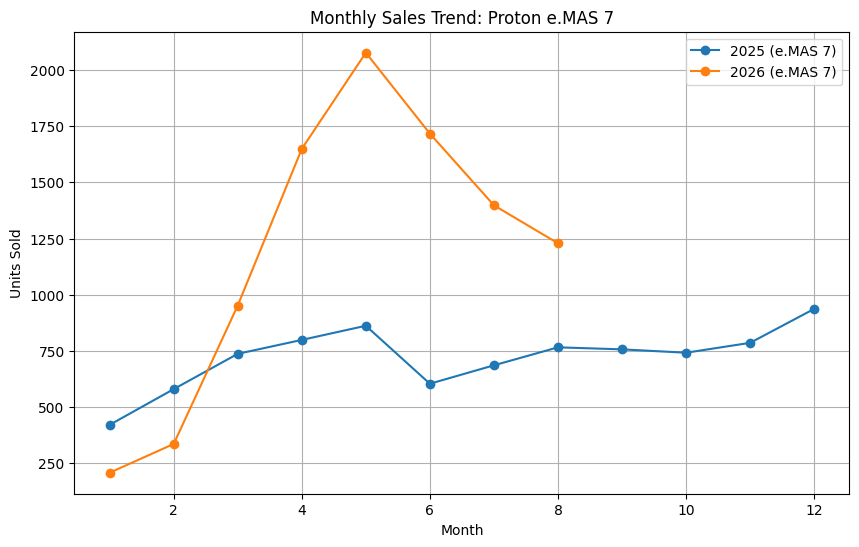

Corrected e.MAS 7 Sales for 2026:
   date_reg  sales
0         1    208
1         2    336
2         3    952
3         4   1649
4         5   2077
5         6   1717
6         7   1398
7         8   1229


In [13]:
import matplotlib.pyplot as plt

# Diagnostic: Check exactly what strings and counts exist for Proton in April 2026
proton_apr_2026 = df_2026[(df_2026['maker'] == 'Proton') & (df_2026['date_reg'].dt.month == 4)]
print("Proton models in April 2026:")
print(proton_apr_2026['model'].value_counts())

# Strictly filter based on exact unique strings found
ema7_mask = (df_2026['maker'] == 'Proton') & (df_2026['model'].str.strip() == 'e.MAS 7')
ema7_2026 = df_2026[ema7_mask].copy()

ema7_mask_25 = (df_2025['maker'] == 'Proton') & (df_2025['model'].str.strip() == 'e.MAS 7')
ema7_2025 = df_2025[ema7_mask_25].copy()

# Grouping
monthly_7_26 = ema7_2026.groupby(ema7_2026['date_reg'].dt.month).size().reset_index(name='sales')
monthly_7_25 = ema7_2025.groupby(ema7_2025['date_reg'].dt.month).size().reset_index(name='sales')

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(monthly_7_25['date_reg'], monthly_7_25['sales'], marker='o', label='2025 (e.MAS 7)')
plt.plot(monthly_7_26['date_reg'], monthly_7_26['sales'], marker='o', label='2026 (e.MAS 7)')
plt.title('Monthly Sales Trend: Proton e.MAS 7')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True)
plt.show()

print("Corrected e.MAS 7 Sales for 2026:")
print(monthly_7_26)

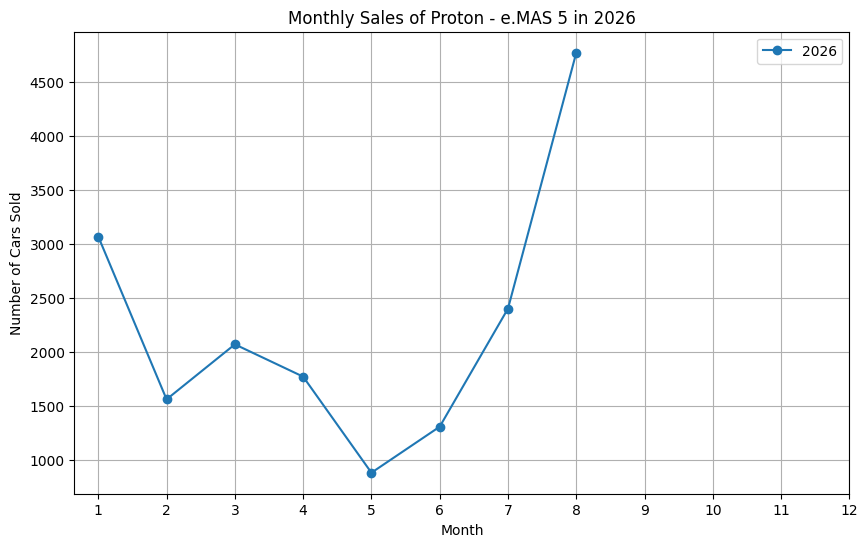

In [14]:
# Filter the DataFrames for 'Proton - e.MAS 5'
proton_emas5_df_2026 = df_2026[(df_2026['maker'] == 'Proton') & (df_2026['model'] == 'e.MAS 5')].copy()

# Group by month and count the sales for 2026
monthly_sales_proton_emas5_2026 = proton_emas5_df_2026.groupby(proton_emas5_df_2026['date_reg'].dt.month).size().reset_index(name='sales')

# Rename the month column for clarity
monthly_sales_proton_emas5_2026 = monthly_sales_proton_emas5_2026.rename(columns={'date_reg': 'month'})

# Plot the monthly sales
plt.figure(figsize=(10, 6))
plt.plot(monthly_sales_proton_emas5_2026['month'], monthly_sales_proton_emas5_2026['sales'], marker='o', linestyle='-', label='2026')
plt.xlabel('Month')
plt.ylabel('Number of Cars Sold')
plt.title('Monthly Sales of Proton - e.MAS 5 in 2026')
plt.xticks(range(1, 13)) # Ensure all 12 months are shown on the x-axis
plt.legend()
plt.grid(True)
plt.show()

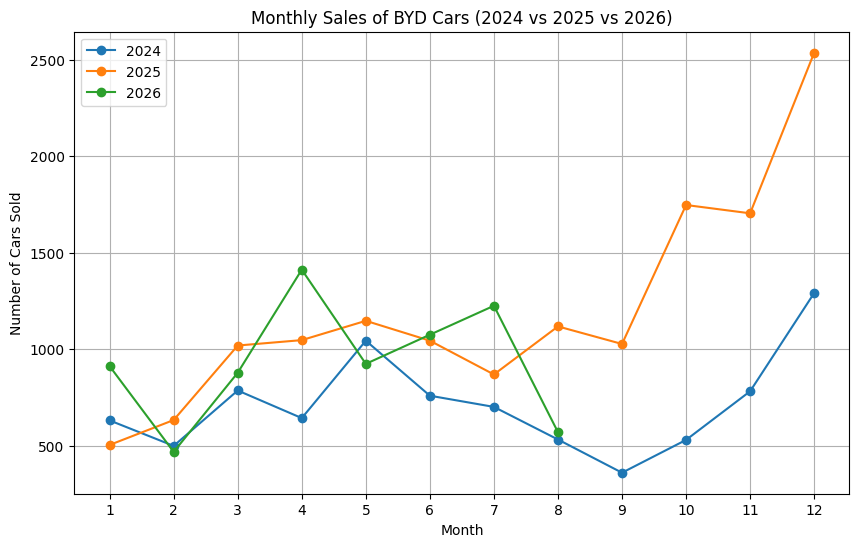

In [15]:
import matplotlib.pyplot as plt

# Filter the DataFrames for 'BYD' maker for 2024, 2025 and 2026
byd_df_2024 = df_2024[df_2024['maker'] == 'BYD'].copy()
byd_df_2025 = df_2025[df_2025['maker'] == 'BYD'].copy()
byd_df_2026 = df_2026[df_2026['maker'] == 'BYD'].copy()

# Group by month and count the sales for 2024
monthly_sales_byd_2024 = byd_df_2024.groupby(byd_df_2024['date_reg'].dt.month).size().reset_index(name='sales')

# Group by month and count the sales for 2025
monthly_sales_byd_2025 = byd_df_2025.groupby(byd_df_2025['date_reg'].dt.month).size().reset_index(name='sales')

# Group by month and count the sales for 2026
monthly_sales_byd_2026 = byd_df_2026.groupby(byd_df_2026['date_reg'].dt.month).size().reset_index(name='sales')

# Rename the month column for clarity (assuming 'date_reg' column in grouped df is month now)
monthly_sales_byd_2024 = monthly_sales_byd_2024.rename(columns={'date_reg': 'month'})
monthly_sales_byd_2025 = monthly_sales_byd_2025.rename(columns={'date_reg': 'month'})
monthly_sales_byd_2026 = monthly_sales_byd_2026.rename(columns={'date_reg': 'month'})

# Plot the monthly sales
plt.figure(figsize=(10, 6))
plt.plot(monthly_sales_byd_2024['month'], monthly_sales_byd_2024['sales'], marker='o', linestyle='-', label='2024')
plt.plot(monthly_sales_byd_2025['month'], monthly_sales_byd_2025['sales'], marker='o', linestyle='-', label='2025')
plt.plot(monthly_sales_byd_2026['month'], monthly_sales_byd_2026['sales'], marker='o', linestyle='-', label='2026')
plt.xlabel('Month')
plt.ylabel('Number of Cars Sold')
plt.title('Monthly Sales of BYD Cars (2024 vs 2025 vs 2026)')
plt.xticks(range(1, 13)) # Ensure all 12 months are shown on the x-axis
plt.legend()
plt.grid(True)
plt.show()

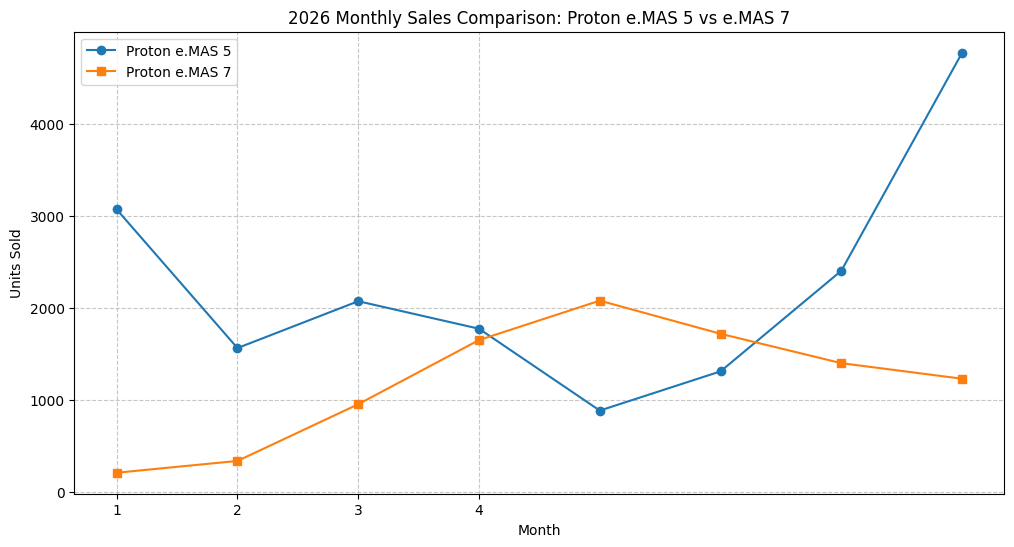

,Month,e.MAS 5 Sales,e.MAS 7 Sales
0,1,3068,208
1,2,1562,336
2,3,2071,952
3,4,1772,1649
4,5,883,2077
5,6,1309,1717
6,7,2402,1398
7,8,4770,1229


In [16]:
import matplotlib.pyplot as plt

# Filter for e.MAS 5 and e.MAS 7 in 2026
emas5_26 = df_2026[(df_2026['maker'] == 'Proton') & (df_2026['model'] == 'e.MAS 5')].copy()
emas7_26 = df_2026[(df_2026['maker'] == 'Proton') & (df_2026['model'] == 'e.MAS 7')].copy()

# Group by month
monthly_5_26 = emas5_26.groupby(emas5_26['date_reg'].dt.month).size().reset_index(name='sales')
monthly_7_26 = emas7_26.groupby(emas7_26['date_reg'].dt.month).size().reset_index(name='sales')

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(monthly_5_26['date_reg'], monthly_5_26['sales'], marker='o', label='Proton e.MAS 5')
plt.plot(monthly_7_26['date_reg'], monthly_7_26['sales'], marker='s', label='Proton e.MAS 7')

plt.title('2026 Monthly Sales Comparison: Proton e.MAS 5 vs e.MAS 7')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.xticks(range(1, 5)) # Data only goes up to April (Month 4)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Print the raw numbers for clarity
comparison_df = pd.merge(monthly_5_26, monthly_7_26, on='date_reg', suffixes=('_eMAS5', '_eMAS7'))
comparison_df.columns = ['Month', 'e.MAS 5 Sales', 'e.MAS 7 Sales']
display(comparison_df)

In [17]:
# Filter for electric cars in 2024
electric_cars_2024 = df_2024[df_2024['fuel'] == 'electric']
total_ev_2024 = len(electric_cars_2024)

# Filter for electric cars in 2025
electric_cars_2025 = df_2025[df_2025['fuel'] == 'electric']
total_ev_2025 = len(electric_cars_2025)

# Filter for electric cars in 2026
electric_cars_2026 = df_2026[df_2026['fuel'] == 'electric']
total_ev_2026 = len(electric_cars_2026)

# Calculate the percentage change year-over-year (2025 vs 2026)
# Handle the case where total_ev_2025 is zero to avoid division by zero
if total_ev_2025 > 0:
    yoy_change_percent = ((total_ev_2026 - total_ev_2025) / total_ev_2025) * 100
else:
    yoy_change_percent = float('inf') if total_ev_2026 > 0 else 0 # Infinite growth if 2026 > 0, else 0 change

print(f"Total electric cars sold in 2024: {total_ev_2024}")
print(f"Total electric cars sold in 2025: {total_ev_2025}")
print(f"Total electric cars sold in 2026: {total_ev_2026}")

if yoy_change_percent == float('inf'):
    print("Year-over-year percentage change (2025 vs 2026): Infinite growth (from 0 sales in 2025)")
else:
    print(f"Year-over-year percentage change (2025 vs 2026): {yoy_change_percent:.2f}%")

Total electric cars sold in 2024: 21788
Total electric cars sold in 2025: 44813
Total electric cars sold in 2026: 47508
Year-over-year percentage change (2025 vs 2026): 6.01%


In [18]:
from google.colab import ai
response = ai.generate_text("What is the best selling car in south east asia?")
print(response)

The best-selling vehicle in Southeast Asia (the ASEAN region) is the **Toyota Hilux**. 

Because Southeast Asia is a highly diverse region with different market preferences, the definition of the "best-selling car" changes slightly depending on whether you count pickup trucks or strictly passenger cars/MPVs. 

Here is the breakdown of the best-selling vehicles in the region based on recent data (2023/2024):

---

### 1. The Overall Best-Seller: **Toyota Hilux**
The Toyota Hilux pickup truck consistently holds the #1 spot for overall vehicle sales in Southeast Asia. 
* **Why it wins:** It is overwhelmingly dominant in **Thailand** (the second-largest automotive market in ASEAN and a global hub for pickup manufacturing) and is also incredibly popular in the **Philippines** and **Vietnam**. 

### 2. The Runner-Up (Overall): **Isuzu D-Max**
Just behind the Hilux is another mid-size pickup truck, the Isuzu D-Max. Like the Hilux, its sales are heavily concentrated in Thailand, where pickup t

In [19]:
import pandas as pd

# Filter for hybrid fuel types in 2026
hybrid_types = ['hybrid_petrol', 'hybrid_diesel']
df_hybrid_2026 = df_2026[df_2026['fuel'].isin(hybrid_types)].copy()

# Group by model and maker to count sales
top_10_hybrids_2026 = df_hybrid_2026.groupby(['maker', 'model', 'fuel']).size().reset_index(name='sold_count')

# Sort and get the top 10
top_10_hybrids_2026 = top_10_hybrids_2026.sort_values(by='sold_count', ascending=False).head(10)

print("Top 10 Best-Selling Hybrid Cars in 2026 (Jan - Apr):")
display(top_10_hybrids_2026)

Top 10 Best-Selling Hybrid Cars in 2026 (Jan - Apr):


,maker,model,fuel,sold_count
74,Proton,e.MAS 7,hybrid_petrol,5562
81,Toyota,Corolla Cross,hybrid_petrol,4129
88,Toyota,Vios,hybrid_petrol,3611
91,Toyota,Yaris Cross,hybrid_petrol,2557
21,Great Wall,Haval H6,hybrid_petrol,2184
24,Great Wall,Wey G9,hybrid_petrol,1769
28,Honda,HR-V,hybrid_petrol,1750
25,Honda,CR-V,hybrid_petrol,1386
69,Nissan,Serena,hybrid_petrol,1274
15,Chery,Tiggo Cross,hybrid_petrol,1163


In [20]:
# Filter for hybrid fuel types and search for 'Hybrid' or 'HEV' to identify naming conventions
phev_df_2026 = df_2026[df_2026['fuel'].isin(['hybrid_petrol', 'hybrid_diesel'])].copy()

# Group and count to see the top labeled hybrid models
top_hybrids_check = phev_df_2026.groupby(['maker', 'model', 'fuel']).size().reset_index(name='sold_count')
top_hybrids_check = top_hybrids_check.sort_values(by='sold_count', ascending=False).head(20)

print("Top 20 Hybrid-labeled Models (Jan - Apr 2026) to identify PHEV naming:")
display(top_hybrids_check)

Top 20 Hybrid-labeled Models (Jan - Apr 2026) to identify PHEV naming:


,maker,model,fuel,sold_count
74,Proton,e.MAS 7,hybrid_petrol,5562
81,Toyota,Corolla Cross,hybrid_petrol,4129
88,Toyota,Vios,hybrid_petrol,3611
91,Toyota,Yaris Cross,hybrid_petrol,2557
21,Great Wall,Haval H6,hybrid_petrol,2184
24,Great Wall,Wey G9,hybrid_petrol,1769
28,Honda,HR-V,hybrid_petrol,1750
25,Honda,CR-V,hybrid_petrol,1386
69,Nissan,Serena,hybrid_petrol,1274
15,Chery,Tiggo Cross,hybrid_petrol,1163


### Identification of Plug-in Hybrids (PHEV)
As the dataset uses the generic `hybrid_petrol` fuel label, we identify PHEVs by cross-referencing known models that dominate the plug-in market. Key PHEV models in this list include luxury segments from Mercedes-Benz, BMW, and Volvo.

In [21]:
# Define a list of known PHEV models likely categorized as hybrid_petrol
known_phev_models = ['C-Class', 'E-Class', 'GLC', '5 Series', 'X5', 'XC60', 'XC90', 'S60', '7 Series', 'Panamera']

# Filter the 2026 data for these specific models within the hybrid fuel types
phev_confirmed_2026 = df_2026[
    df_2026['fuel'].isin(['hybrid_petrol', 'hybrid_diesel']) &
    df_2026['model'].str.contains('|'.join(known_phev_models), case=False, na=False)
].copy()

# Group and rank
top_10_phev_market = phev_confirmed_2026.groupby(['maker', 'model']).size().reset_index(name='sold_count')
top_10_phev_market = top_10_phev_market.sort_values(by='sold_count', ascending=False).head(10)

print("Top 10 Estimated PHEV Sales in 2026 (Jan - Apr) based on Model Research:")
display(top_10_phev_market)

Top 10 Estimated PHEV Sales in 2026 (Jan - Apr) based on Model Research:


,maker,model,sold_count
2,Mercedes Benz,C-Class,638
4,Mercedes Benz,GLC,581
3,Mercedes Benz,E-Class,557
0,BMW,5 Series,235
6,Volvo,XC60,205
7,Volvo,XC90,175
1,BMW,7 Series,65
5,Porsche,Panamera,1


In [22]:
import pandas as pd

# Filter for all e.MAS 7 registrations to check fuel distribution
emas7_fuel_check = df[df['model'].str.strip() == 'e.MAS 7'].groupby('fuel').size().reset_index(name='units')

print("Fuel types recorded for Proton e.MAS 7 (Total Dataset):")
display(emas7_fuel_check)

print("\nTechnical Note: The Proton e.MAS 7 is marketed as a Battery Electric Vehicle (BEV).")

Fuel types recorded for Proton e.MAS 7 (Total Dataset):


,fuel,units
0,electric,12681
1,hybrid_petrol,5562



Technical Note: The Proton e.MAS 7 is marketed as a Battery Electric Vehicle (BEV).
